1. Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize purchased and not_purchased data distribution based on age and estimated salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the customer will purchase a mobile or not.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
data = pd.read_csv("mobile.csv")

print(data.head())

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [5]:
print("Rows and Columns:", data.shape)

Rows and Columns: (400, 3)


In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB
None


In [7]:
print(data.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [8]:
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['EstimatedSalary'].fillna(data['EstimatedSalary'].mean(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13200\1966702626.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13200\1966702626.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [9]:
print(data.isnull().sum())


Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


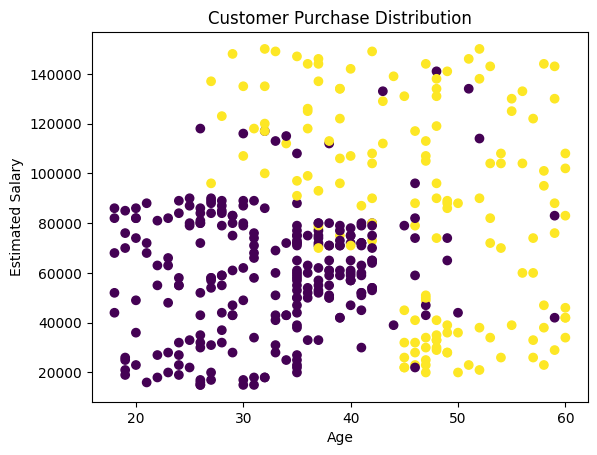

In [10]:
plt.scatter(data['Age'], data['EstimatedSalary'], c=data['Purchased'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Purchase Distribution")
plt.show()

In [11]:
X = data[['Age','EstimatedSalary']]
y = data['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1]


In [16]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc*100)

Confusion Matrix
[[55  3]
 [ 1 21]]
Accuracy: 95.0


In [17]:
new_customer = scaler.transform([[35,50000]])

prediction = model.predict(new_customer)

if prediction==1:
    print("Customer will purchase mobile")
else:
    print("Customer will NOT purchase mobile")

Customer will NOT purchase mobile


c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



2. Apply suitable Regression.

Read computer.csv dataset. Find no. of columns and rows with given dataset. Which regression model fit with given dataset? Build suitable regression model with the data and fetch intercept and coefficient. Visualize Models using pyplot. Compute the Coefficient of Determination to find accuracy.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [21]:
data = pd.read_csv("computers.csv")
print(data.head())

   Units  Minutes
0      1       23
1      2       29
2      3       49
3      4       64
4      4       74


In [ ]:
data.info()

In [22]:
print("Dataset Shape:", data.shape)

Dataset Shape: (14, 2)


In [23]:
print(data.columns)

Index(['Units', 'Minutes'], dtype='object')


In [24]:
X = data[['Units']]
y = data['Minutes']

In [25]:
model = LinearRegression()

In [26]:
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 4.161654135338296
Coefficient: [15.50877193]


In [28]:
y_pred = model.predict(X)

In [29]:
r2 = r2_score(y, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9874371980620736


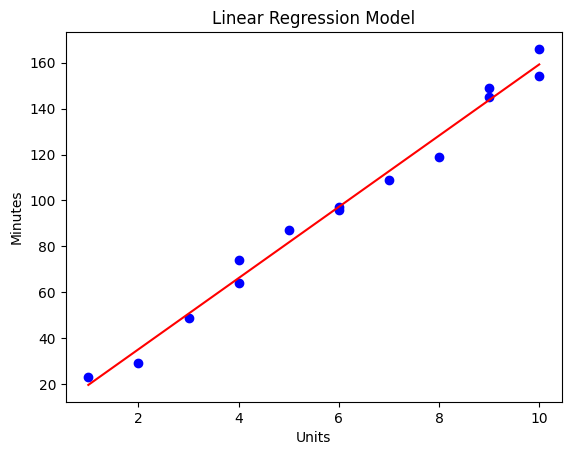

In [ ]:
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')

plt.xlabel("Units")
plt.ylabel("Minutes")
plt.title("Linear Regression Model")

plt.show()
